导入pandas库

In [2]:
import pandas as pd

将福州大学教务处的通知导入到csv文件中，使用read_csv()将csv转变为DataFrame

In [3]:
fpath = "info.csv"
df = pd.read_csv(fpath , header = 0)

统计出现过的通知人

In [4]:
refresh_list = df["通知人"].drop_duplicates()
refresh_list

0      【教学运行】
1       【实践科】
2       【质量办】
4      【教研教改】
7       【综合科】
12      【计划科】
63     【教材中心】
490    【教学通知】
746    【电教中心】
Name: 通知人, dtype: object

统计发布数

In [5]:
num_list = df["通知人"].value_counts()
num_list

通知人
【教学运行】    247
【实践科】     209
【质量办】      93
【计划科】      89
【教研教改】     68
【综合科】      57
【教材中心】     30
【教学通知】      6
【电教中心】      1
Name: count, dtype: int64

获取总量

In [6]:
num = len(df)
num

800

In [7]:
new_num_list = num_list.reset_index()
new_num_list.columns = ["通知人", "发布数"]
new_num_list

,通知人,发布数
0,【教学运行】,247
1,【实践科】,209
2,【质量办】,93
3,【计划科】,89
4,【教研教改】,68
5,【综合科】,57
6,【教材中心】,30
7,【教学通知】,6
8,【电教中心】,1


In [8]:
new_num_list["占比"] = new_num_list["发布数"] / num
new_num_list

,通知人,发布数,占比
0,【教学运行】,247,0.30875
1,【实践科】,209,0.26125
2,【质量办】,93,0.11625
3,【计划科】,89,0.11125
4,【教研教改】,68,0.08500
5,【综合科】,57,0.07125
6,【教材中心】,30,0.03750
7,【教学通知】,6,0.00750
8,【电教中心】,1,0.00125


检验附件下载量和通知人的关系，使用数据聚合，须在处理前进行数据清洗

In [14]:
import ast

# 核心：将字符串列表转为数字总和
def get_sum(x):
    if pd.isna(x) or str(x).strip() == '':
        return 0
    try:
        # 使用 ast.literal_eval 将 "['1', '2']" 转为 [1, 2]
        nums = ast.literal_eval(str(x))
        return sum(int(i) for i in nums if str(i).isdigit())
    except:
        return 0

# 核心逻辑：计算逗号出现的次数 + 1
df['附件个数'] = df['附件下载次数'].str.count(',') + 1
df.loc[df['附件下载次数'].isna() | (df['附件下载次数'] == ''), '附件个数'] = 0

# 先创建一个纯数值列
df['下载量_数值'] = df['附件下载次数'].apply(get_sum)/df['附件个数']
df.tail(10)

,通知人,标题,发布日期,详情链接,附件名,附件下载次数,附件链接,日期,月,附件个数,下载量_数值
790,【质量办】,关于举办福州大学第七十三场“教学有道”研讨活动的通知,2025/9/28,https://jwch.fzu.edu.cn/info/1040/14235.htm,NaN,NaN,NaN,2025-09-28,9,0.0,NaN
791,【教学运行】,关于2025-2026-01学期体育理论教室安排（2025级）的通知,2025/9/26,https://jwch.fzu.edu.cn/info/1036/14232.htm,NaN,NaN,NaN,2025-09-26,9,0.0,NaN
792,【教学运行】,关于2025年国庆节、中秋节放假课程调整的通知,2025/9/24,https://jwch.fzu.edu.cn/info/1036/14229.htm,NaN,NaN,NaN,2025-09-24,9,0.0,NaN
793,【综合科】,关于召开2025-2026学年秋季学期期初本科教育教学工作会议的通知,2025/9/23,https://jwch.fzu.edu.cn/info/1035/14228.htm,NaN,NaN,NaN,2025-09-23,9,0.0,NaN
794,【实践科】,关于举办2025年福州大学大学生工程实践与创新能力大赛的通知,2025/9/23,https://jwch.fzu.edu.cn/content.jsp?urltype=ne...,"['附件1：2025年福州大学大学生工程实践与创新能力大赛组委会成员名单.docx', '附...","['111', '142', '337']",['/system/_content/download.jsp?urltype=news.D...,2025-09-23,9,3.0,196.666667
795,【教学运行】,关于做好2025-2026学年第二学期排课准备工作的通知,2025/9/22,https://jwch.fzu.edu.cn/info/1036/14225.htm,NaN,NaN,NaN,2025-09-22,9,0.0,NaN
796,【教学运行】,关于2025-2026学年第一学期重新学习选课、缴费的通知,2025/9/22,https://jwch.fzu.edu.cn/info/1036/14224.htm,NaN,NaN,NaN,2025-09-22,9,0.0,NaN
797,【计划科】,关于2025-2026学年第一学期参加《大学生国家安全教育》课程学习的通知,2025/9/22,https://jwch.fzu.edu.cn/info/1038/14223.htm,['超星尔雅使用手册（学生版）.pdf'],['3146'],['/system/_content/download.jsp?urltype=news.D...,2025-09-22,9,1.0,3146.000000
798,【计划科】,关于通识教育选修课《国际化拔尖创新人才科研训练2025秋》宣讲会及选课的通知,2025/9/19,https://jwch.fzu.edu.cn/info/1038/14220.htm,['2025年秋季国际化拔尖创新人才科研训练具体课程清单.xlsx'],['1274'],['/system/_content/download.jsp?urltype=news.D...,2025-09-19,9,1.0,1274.000000
799,【计划科】,关于2025-2026学年第一学期爱课程平台参加通识教育选修课学习的重要提示,2025/9/18,https://jwch.fzu.edu.cn/info/1038/14219.htm,NaN,NaN,NaN,2025-09-18,9,0.0,NaN


In [15]:
load = df.groupby("通知人")["下载量_数值"].mean()
load

通知人
【实践科】     2244.822493
【教学运行】    1159.995305
【教学通知】     462.500000
【教材中心】     802.909649
【教研教改】    1503.842534
【电教中心】            NaN
【综合科】      716.906250
【计划科】     2016.476190
【质量办】     1013.493902
Name: 下载量_数值, dtype: float64

统计月份与通知发布的关系

In [16]:
df["日期"]=pd.to_datetime(df["发布日期"] , format="%Y/%m/%d")
df["月"]=df["日期"].dt.month
month_list = df["月"].value_counts()
month_list

月
9     111
5     110
4      96
6      95
12     72
3      71
11     57
8      49
10     45
2      37
1      30
7      27
Name: count, dtype: int64

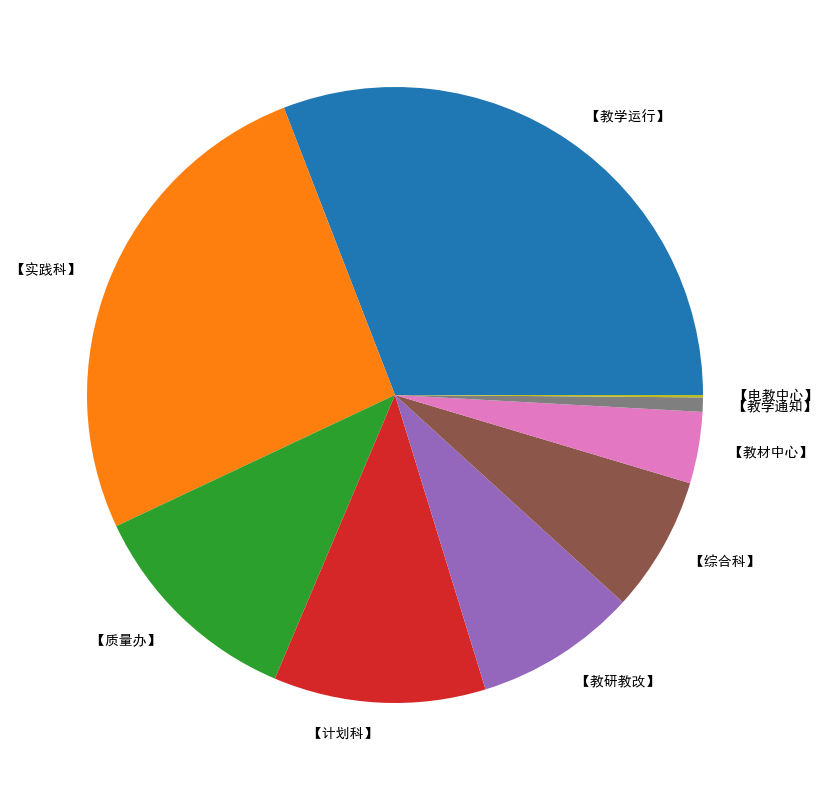

In [11]:
#制图
import matplotlib.pyplot as plt
import numpy as np
#解决汉字无法显示
from matplotlib import rcParams #字体
rcParams['font.family'] = ['SimHei']

plt.figure(figsize = (12,8))
plt.pie(new_num_list["发布数"],labels=new_num_list["通知人"])
plt.title("通知发布数")
plt.tight_layout()  #自动优化排版
plt.show()

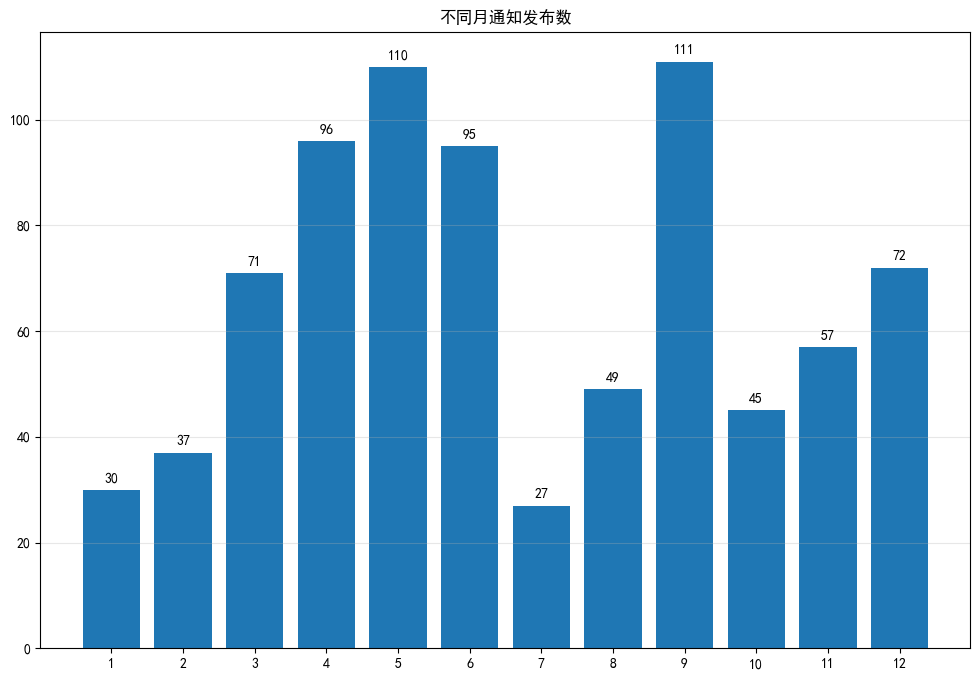

In [22]:
#制图
plt.figure(figsize = (12,8))
plt.bar(month_list.index,month_list.values)
plt.title("不同月通知发布数")
plt.xticks(range(1,13))
plt.grid(axis='y', alpha=0.3)
for x,y in zip(month_list.index,month_list.values):
    plt.text(x,y+1,str(y),ha='center',va='bottom',fontsize=10)
plt.show()